# xNES learning-rate sweeps

This notebook tunes the xNES learning-rate knobs `eta_mu`, `eta_sigma`, and `eta_B` with explicit center values defined at the top of the notebook.

- Each sweep changes one knob while the other two stay at their configured center values.
- Optimization is driven by noisy translated objectives.
- `sphere` provides the separable baseline.
- `ellipsoid` and `cigar` are rotated generically per case to stress shape adaptation without rotating every function.
- Each `function x dimension x trial` case reuses the same optimizer and noise RNG streams across eta settings.
- Scoring uses the clean objective at the current mean on log-spaced checkpoints through the run, averaged as a log-time AOC approximation.

In [35]:
from __future__ import annotations

from collections.abc import Callable
from itertools import product

import matplotlib.pyplot as plt
import numpy as np
from tqdm.notebook import tqdm

from leitwerk import XNES, XNESStatus
from leitwerk.xnes import _default_sample_count

In [36]:
MASTER_SEED = 1234

ETA_MU_CENTER = 1.0
ETA_SIGMA_CENTER = 0.5
ETA_B_CENTER = 0.25

ETA_MU_LOG_MIN = -1
ETA_SIGMA_LOG_MIN = -1
ETA_B_LOG_MIN = -1
RESOLUTION = 100
NUM_TRIALS = 1
DIMENSION = [3, 10, 30]
NOISE_SCALE = 1e-1

X0 = 0.0
SIGMA0 = 1.0

MAX_GENERATIONS = 128
OFFSET_SCALE = 3.0
SCORE_EPS = 1e-12
SCORE_CLIP = 6.0

FUNCTION_NAMES = ("sphere", "ackley", "rosenbrock", "ellipsoid", "cigar")
ROTATED_FUNCTIONS = frozenset({"ellipsoid", "cigar"})
CENTER_ETAS = {
    "eta_mu": ETA_MU_CENTER,
    "eta_sigma": ETA_SIGMA_CENTER,
    "eta_B": ETA_B_CENTER,
}


def make_eta_sweep(log_min: int) -> np.ndarray:
    if RESOLUTION < 1:
        msg = "RESOLUTION must be at least 1 for a positive log sweep."
        raise ValueError(msg)
    sweep = np.logspace(log_min, 0.0, RESOLUTION, base=10.0, dtype=float)
    sweep[-1] = 1.0
    return sweep


def make_checkpoints(max_generations: int) -> list[int]:
    checkpoints: list[int] = []
    generation = 1
    while generation < max_generations:
        checkpoints.append(generation)
        generation *= 2
    checkpoints.append(max_generations)
    return checkpoints


ETA_SWEEPS = {
    "eta_mu": make_eta_sweep(ETA_MU_LOG_MIN),
    "eta_sigma": make_eta_sweep(ETA_SIGMA_LOG_MIN),
    "eta_B": make_eta_sweep(ETA_B_LOG_MIN),
}
CHECKPOINT_GENERATIONS = make_checkpoints(MAX_GENERATIONS)
CASES = list(product(FUNCTION_NAMES, DIMENSION, range(NUM_TRIALS)))
CASE_COUNT = len(CASES)

print(
    {
        "center_etas": CENTER_ETAS,
        "functions": FUNCTION_NAMES,
        "rotated_functions": sorted(ROTATED_FUNCTIONS),
        "dimensions": DIMENSION,
        "num_trials": NUM_TRIALS,
        "resolution": RESOLUTION,
        "max_generations": MAX_GENERATIONS,
        "checkpoint_generations": CHECKPOINT_GENERATIONS,
        "noise_scale": NOISE_SCALE,
        "cases_per_eta": CASE_COUNT,
    }
)

{'center_etas': {'eta_mu': 1.0, 'eta_sigma': 0.5, 'eta_B': 0.25}, 'functions': ('sphere', 'ackley', 'rosenbrock', 'ellipsoid', 'cigar'), 'rotated_functions': ['cigar', 'ellipsoid'], 'dimensions': [3, 10, 30], 'num_trials': 1, 'resolution': 100, 'max_generations': 128, 'checkpoint_generations': [1, 2, 4, 8, 16, 32, 64, 128], 'noise_scale': 0.1, 'cases_per_eta': 15}


In [37]:
def _as_matrix(points: np.ndarray) -> np.ndarray:
    x = np.asarray(points, dtype=float)
    if x.ndim == 1:
        return x[:, None]
    if x.ndim != 2:
        msg = "points must have shape (dim,) or (dim, n)."
        raise ValueError(msg)
    return x


def ackley(points: np.ndarray) -> np.ndarray:
    x = _as_matrix(points)
    mean_sq = np.mean(x**2, axis=0)
    mean_cos = np.mean(np.cos(2.0 * np.pi * x), axis=0)
    return -20.0 * np.exp(-0.2 * np.sqrt(mean_sq)) - np.exp(mean_cos) + 20.0 + np.e


def sphere(points: np.ndarray) -> np.ndarray:
    x = _as_matrix(points)
    return np.sum(x**2, axis=0)


def centered_rosenbrock(points: np.ndarray) -> np.ndarray:
    x = _as_matrix(points)
    if x.shape[0] == 1:
        return x[0] ** 2
    shifted = x + 1.0
    return np.sum(100.0 * (shifted[1:] - shifted[:-1] ** 2) ** 2 + (1.0 - shifted[:-1]) ** 2, axis=0)


def ellipsoid(points: np.ndarray) -> np.ndarray:
    x = _as_matrix(points)
    weights = 1.0e6 ** np.linspace(0.0, 1.0, x.shape[0], dtype=float)
    return np.sum(weights[:, None] * x**2, axis=0)


def cigar(points: np.ndarray) -> np.ndarray:
    x = _as_matrix(points)
    if x.shape[0] == 1:
        return x[0] ** 2
    return x[0] ** 2 + 1.0e6 * np.sum(x[1:] ** 2, axis=0)


OBJECTIVES: dict[str, Callable[[np.ndarray], np.ndarray]] = {
    "sphere": sphere,
    "ackley": ackley,
    "rosenbrock": centered_rosenbrock,
    "ellipsoid": ellipsoid,
    "cigar": cigar,
}


def random_rotation(dim: int, rng: np.random.Generator) -> np.ndarray:
    if dim <= 1:
        return np.eye(dim)
    raw = rng.standard_normal((dim, dim))
    q, r = np.linalg.qr(raw)
    signs = np.sign(np.diag(r))
    signs[signs == 0.0] = 1.0
    return q * signs


def make_case_streams(function_name: str, dim: int, trial_index: int) -> tuple[np.random.SeedSequence, np.random.SeedSequence]:
    function_index = FUNCTION_NAMES.index(function_name)
    case_seed = np.random.SeedSequence([MASTER_SEED, function_index, dim, trial_index])
    problem_seed, optimizer_seed = case_seed.spawn(2)
    return problem_seed, optimizer_seed


def make_problem(
    function_name: str,
    dim: int,
    problem_seed: np.random.SeedSequence,
) -> tuple[Callable[[np.ndarray], np.ndarray], Callable[[np.ndarray], np.ndarray], np.ndarray, bool]:
    offset_seed, noise_seed, rotation_seed = problem_seed.spawn(3)
    offset_rng = np.random.default_rng(offset_seed)
    noise_rng = np.random.default_rng(noise_seed)
    rotation_rng = np.random.default_rng(rotation_seed)
    offset = offset_rng.uniform(-OFFSET_SCALE, OFFSET_SCALE, size=dim)
    rotation_applied = function_name in ROTATED_FUNCTIONS and dim > 1
    rotation = random_rotation(dim, rotation_rng) if rotation_applied else np.eye(dim)
    objective = OBJECTIVES[function_name]

    def clean(points: np.ndarray) -> np.ndarray:
        x = _as_matrix(points)
        centered = x - offset[:, None]
        transformed = rotation.T @ centered
        return objective(transformed)

    def noisy(points: np.ndarray) -> np.ndarray:
        base = clean(points)
        noise = NOISE_SCALE * (1.0 + base) * np.abs(noise_rng.standard_normal(base.shape))
        return base + noise

    return clean, noisy, offset, rotation_applied


def log_improvement(initial_clean: float, current_clean: float) -> float:
    residual = (current_clean + SCORE_EPS) / (initial_clean + SCORE_EPS)
    residual = float(np.clip(residual, 10.0 ** -SCORE_CLIP, 10.0 ** SCORE_CLIP))
    return -float(np.log10(residual))


def run_trial(function_name: str, dim: int, trial_index: int, etas: dict[str, float]) -> dict[str, float | int | str | bool]:
    problem_seed, optimizer_seed = make_case_streams(function_name, dim, trial_index)
    clean, noisy, offset, rotation_applied = make_problem(function_name, dim, problem_seed)
    xnes = XNES(np.full(dim, X0, dtype=float), SIGMA0)
    rng = np.random.default_rng(optimizer_seed)
    population_size = _default_sample_count(None, dim)

    initial_clean = float(clean(xnes.mu)[0])
    current_clean = initial_clean
    status = XNESStatus.OK
    generations = 0
    checkpoint_scores: list[float] = []
    next_checkpoint_index = 0
    last_score = 0.0

    for generation in range(1, MAX_GENERATIONS + 1):
        z = xnes.sample_distribution(population_size, rng=rng)
        x = xnes.transform(z)
        values = noisy(x)
        ranking = np.argsort(values, kind="stable").tolist()
        status = xnes.update_distribution(z, ranking, **etas)
        generations = generation

        current_clean = float(clean(xnes.mu)[0])
        last_score = log_improvement(initial_clean, current_clean)
        while next_checkpoint_index < len(CHECKPOINT_GENERATIONS) and generation >= CHECKPOINT_GENERATIONS[next_checkpoint_index]:
            checkpoint_scores.append(last_score)
            next_checkpoint_index += 1

        if status is not XNESStatus.OK:
            break

    while len(checkpoint_scores) < len(CHECKPOINT_GENERATIONS):
        checkpoint_scores.append(last_score)

    return {
        "function": function_name,
        "dimension": dim,
        "trial": trial_index,
        "rotated": rotation_applied,
        "offset_norm": float(np.linalg.norm(offset)),
        "population_size": population_size,
        "generations": generations,
        "status": status.name,
        "initial_clean": initial_clean,
        "final_clean": current_clean,
        "final_score": checkpoint_scores[-1],
        "score": float(np.mean(checkpoint_scores)),
    }

In [38]:
results: list[dict[str, float | int | str | bool]] = []

for knob, sweep_values in ETA_SWEEPS.items():
    for eta_value in tqdm(sweep_values, desc=knob):
        etas = dict(CENTER_ETAS)
        etas[knob] = float(eta_value)
        for function_name, dim, trial_index in CASES:
            row = run_trial(function_name, dim, trial_index, etas)
            row.update({"knob": knob, "eta_value": float(eta_value)})
            results.append(row)

print(f"{len(results)=} ({CASE_COUNT} cases per eta)")

eta_mu:   0%|          | 0/100 [00:00<?, ?it/s]

eta_sigma:   0%|          | 0/100 [00:00<?, ?it/s]

eta_B:   0%|          | 0/100 [00:00<?, ?it/s]

len(results)=4500 (15 cases per eta)


In [39]:
aggregate: dict[str, dict[str, np.ndarray]] = {}
best_by_knob: list[dict[str, float | str | tuple[float, float]]] = []

for knob, sweep_values in ETA_SWEEPS.items():
    knob_rows = [row for row in results if row["knob"] == knob]
    scores = np.array([float(row["score"]) for row in knob_rows], dtype=float).reshape(len(sweep_values), CASE_COUNT)
    failures = np.array([row["status"] != "OK" for row in knob_rows], dtype=float).reshape(len(sweep_values), CASE_COUNT)

    stats = {
        "eta_values": sweep_values,
        "mean": scores.mean(axis=1),
        "q05": np.quantile(scores, 0.05, axis=1),
        "q25": np.quantile(scores, 0.25, axis=1),
        "q75": np.quantile(scores, 0.75, axis=1),
        "q95": np.quantile(scores, 0.95, axis=1),
        "failure_rate": failures.mean(axis=1),
    }
    aggregate[knob] = stats

    best_index = int(np.argmax(stats["mean"]))
    best_by_knob.append(
        {
            "knob": knob,
            "best_eta": float(stats["eta_values"][best_index]),
            "mean_aoc_score": float(stats["mean"][best_index]),
            "iqr": (
                float(stats["q25"][best_index]),
                float(stats["q75"][best_index]),
            ),
            "tail_band": (
                float(stats["q05"][best_index]),
                float(stats["q95"][best_index]),
            ),
            "failure_rate": float(stats["failure_rate"][best_index]),
        }
    )

best_by_knob

[{'knob': 'eta_mu',
  'best_eta': 0.8497534359086445,
  'mean_aoc_score': 1.6714883099053721,
  'iqr': (1.2206150311100918, 1.9289926569233469),
  'tail_band': (0.7055087475211654, 2.8842303112190693),
  'failure_rate': 0.0},
 {'knob': 'eta_sigma',
  'best_eta': 0.7924828983539175,
  'mean_aoc_score': 1.7036617281188398,
  'iqr': (1.3378484154876773, 1.9449857221113787),
  'tail_band': (0.7821847593503416, 2.6610068862662914),
  'failure_rate': 0.0},
 {'knob': 'eta_B',
  'best_eta': 0.9770099572992254,
  'mean_aoc_score': 1.7132139176323873,
  'iqr': (1.3314688378290316, 1.9444153572539116),
  'tail_band': (0.6773704608820308, 3.0181433693249073),
  'failure_rate': 0.0}]

## Sweep plots

Each plot aggregates the checkpoint-averaged log-time AOC score across all dimensions, functions, and trials for one knob.

- Dark band: interquartile range (25%-75%)
- Light band: tail band (5%-95%)
- Dashed line: configured center value for that knob

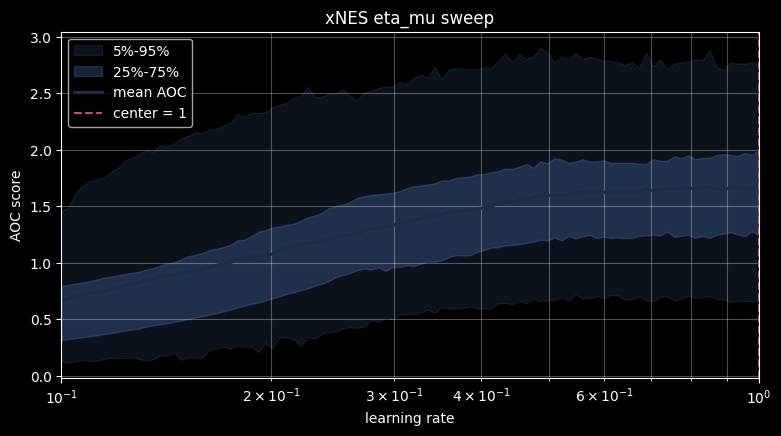

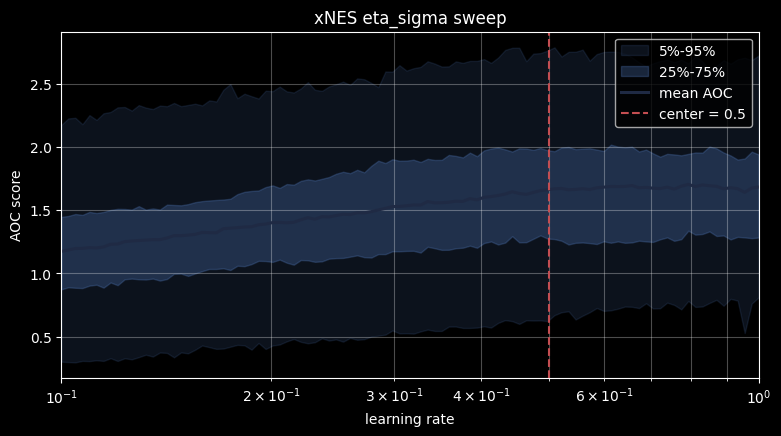

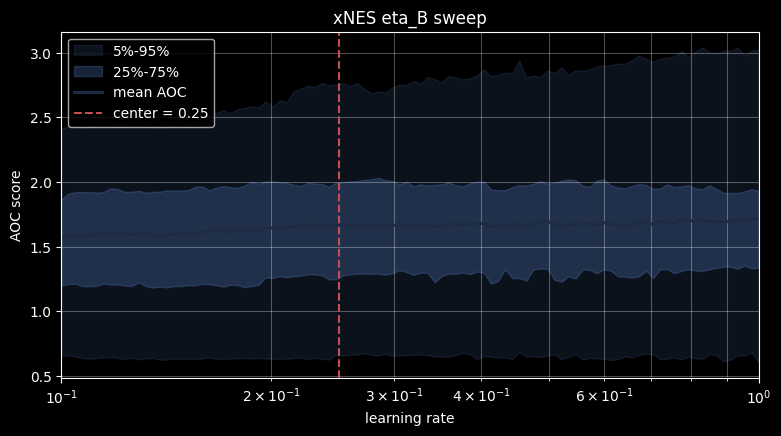

In [40]:
for knob in ("eta_mu", "eta_sigma", "eta_B"):
    stats = aggregate[knob]
    eta_values = stats["eta_values"]

    fig, ax = plt.subplots(figsize=(9, 4.5))
    ax.fill_between(eta_values, stats["q05"], stats["q95"], color="#4c72b0", alpha=0.16, label="5%-95%")
    ax.fill_between(eta_values, stats["q25"], stats["q75"], color="#4c72b0", alpha=0.32, label="25%-75%")
    ax.plot(eta_values, stats["mean"], color="#1f2a44", linewidth=2.2, label="mean AOC")
    ax.axvline(CENTER_ETAS[knob], color="#c44e52", linestyle="--", linewidth=1.5, label=f"center = {CENTER_ETAS[knob]:g}")

    ax.set_xscale("log")
    ax.set_xlim(float(np.min(eta_values)), float(np.max(eta_values)))
    ax.set_xlabel("learning rate")
    ax.set_ylabel("AOC score")
    ax.set_title(f"xNES {knob} sweep")
    ax.grid(True, which="both", alpha=0.3)
    ax.legend(loc="best")
    plt.show()